<a href="https://colab.research.google.com/github/kipruto45/kipruto45/blob/main/stock_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM (Long Short-Term Memory) for Time Series Prediction
In this tutorial, we'll explore Long Short-Term Memory (LSTM) networks, a type of Recurrent Neural Network (RNN) designed to capture long-term dependencies in sequential data. LSTMs are particularly effective for time series prediction, where the order of data points matters.

# Introduction to LSTMs
LSTMs are a special kind of RNN capable of learning long-term dependencies. Unlike standard RNNs, LSTMs have mechanisms called gates that regulate the flow of information, making them better suited for tasks where context from previous data points is crucial.

# Dataset Overview
For this tutorial, we'll use a stock market dataset from Kaggle. The dataset contains historical stock prices, including open, close, high, low prices, and volume. We'll focus on predicting the closing price based on past data.

### Data Preprocessing
Before feeding the data into our LSTM model, we need to preprocess it:

* **Normalization**: LSTMs perform better when the input data is normalized.

* **Data Splitting**: We'll divide the dataset into training and testing sets.

* **Sequence Creation**: Since LSTMs require sequential input, we'll create sequences of stock prices to train the model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset

In [2]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Data sets/GOOG.csv')  # Replace with your dataset's path
df.head()

# Selecting 'Close' column and normalizing it
scaler = MinMaxScaler(feature_range=(0, 1))
df_close = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

In [3]:
# Creating sequences of data
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length])
    return np.array(sequences), np.array(labels)

seq_length = 50
X, y = create_sequences(df_close, seq_length)

In [4]:
# Splitting into training and testing sets
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

### Building the LSTM Model
Next, we define the LSTM model. Our model will have one LSTM layer followed by a fully connected layer to output the prediction.

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [6]:
input_size = 1
hidden_size = 64
num_layers = 2
output_size = 1

model = LSTMModel(input_size, hidden_size, num_layers, output_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Training the Model
We'll train the LSTM model using the training dataset. The model will try to minimize the mean squared error between the predicted and actual stock prices.

In [7]:
# Custom Dataset class
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [8]:
# Create an instance of the dataset
train_data = StockDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_data, batch_size=50, shuffle=True)

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    for sequences, labels in train_loader:
        outputs = model(sequences)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}')


Epoch 1/10, Loss: 0.0010
Epoch 2/10, Loss: 0.0001
Epoch 3/10, Loss: 0.0001
Epoch 4/10, Loss: 0.0000
Epoch 5/10, Loss: 0.0000
Epoch 6/10, Loss: 0.0000
Epoch 7/10, Loss: 0.0001
Epoch 8/10, Loss: 0.0001
Epoch 9/10, Loss: 0.0000
Epoch 10/10, Loss: 0.0000


### Evaluating the Model
After training, we evaluate the model's performance on the test set. We'll also visualize the predicted vs. actual stock prices.

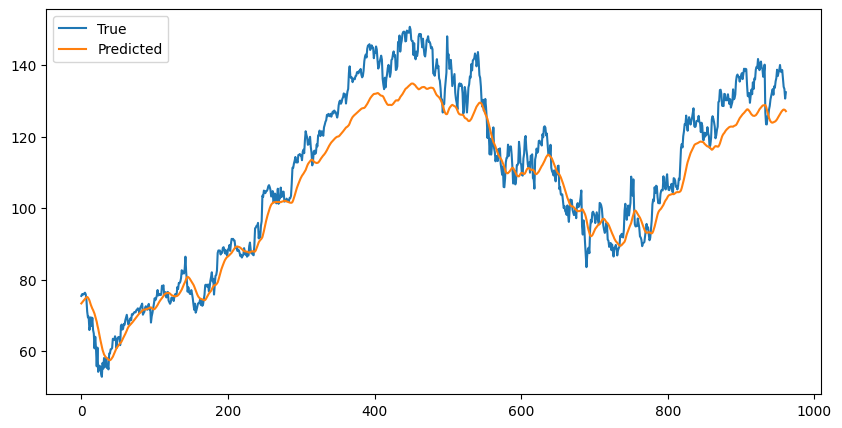

In [9]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    predictions = predictions.detach().numpy()
    predictions = scaler.inverse_transform(predictions)
    y_test = y_test_tensor.numpy()
    y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(10, 5))
plt.plot(y_test, label='True')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.show()